In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/Users/senarajayawardena/Documents/Dialog/finsight_clean.csv')

for col in ['Customer_Segment', 'Province', 'Urban_Rural']:
    print(f'\n--- By {col} ---')
    print(df.groupby(col)['Savings_Balance']
            .agg(['mean', 'median', 'count'])
            .sort_values('mean', ascending=False)
            .round(0))


--- By Customer_Segment ---
                       mean     median  count
Customer_Segment                             
Premium           2654140.0  2504760.0     91
Regular            425859.0   448867.0    319
Starter             82246.0    85046.0     93
Unknown                 NaN        NaN      0

--- By Province ---
                   mean    median  count
Province                                
Eastern        934620.0  540962.0     50
Sabaragamuwa   879928.0  409667.0     58
Western        837397.0  448582.0    104
North Western  771320.0  510987.0     55
Central        726492.0  448867.0     47
Northern       662592.0  398756.0     59
Southern       656488.0  379254.0     81
Uva            639433.0  420440.0     49

--- By Urban_Rural ---
                 mean    median  count
Urban_Rural                           
Urban        888128.0  510987.0    189
Rural        730859.0  418672.0    125
Suburban     665666.0  368721.0    189


## Q1a - Average Savings Balance by Segment, Province & Urban/Rural

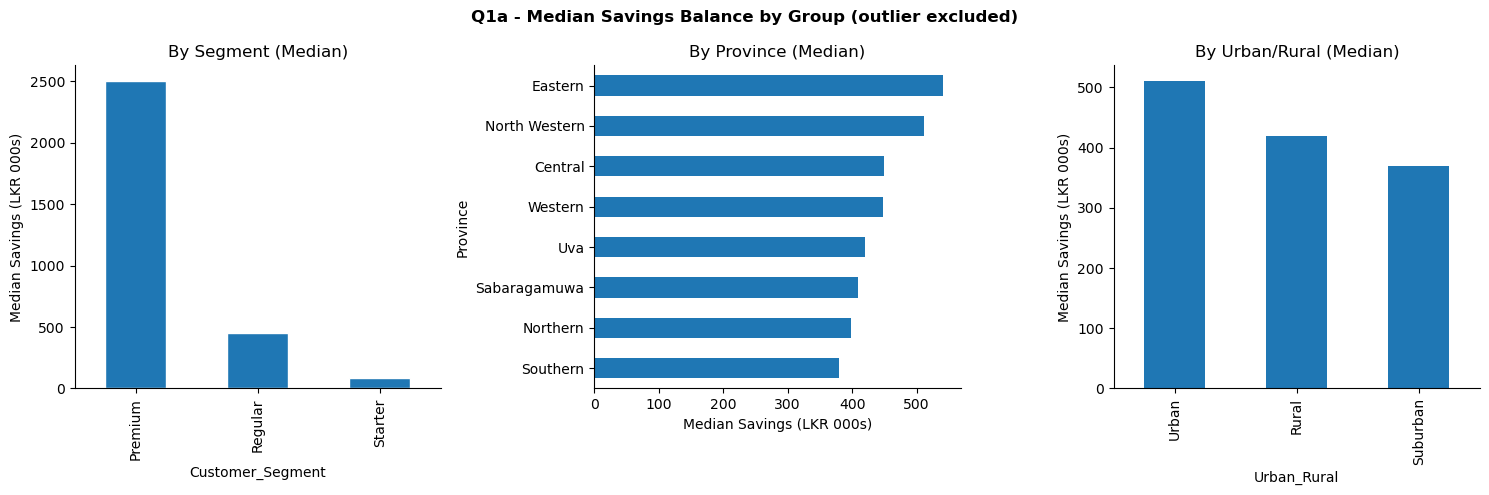

In [14]:
df_clean = df[df["Savings_Balance"] < 999_000_000]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Q1a - Median Savings Balance by Group (outlier excluded)', fontweight='bold')

df_clean.groupby('Customer_Segment')['Savings_Balance'].median().sort_values(ascending=False).div(1000).plot.bar(ax=axes[0], edgecolor='white')
axes[0].set(title='By Segment (Median)', ylabel='Median Savings (LKR 000s)')

df_clean.groupby('Province')['Savings_Balance'].median().sort_values().div(1000).plot.barh(ax=axes[1])
axes[1].set(title='By Province (Median)', xlabel='Median Savings (LKR 000s)')

df_clean.groupby('Urban_Rural')['Savings_Balance'].median().sort_values(ascending=False).div(1000).plot.bar(ax=axes[2])
axes[2].set(title='By Urban/Rural (Median)', ylabel='Median Savings (LKR 000s)')

for ax in axes: ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## Q1b - Age Group Hwith the Highest Total Savings

Age_Band        Total          Mean    Median  Count
   18-24 4.844363e+07 712406.260000 360107.16     68
   25-34 1.264052e+08 826178.035163 477760.52    153
   35-44 1.168049e+08 794590.834898 461148.18    147
   45-54 9.195474e+07 701944.605992 448866.68    131
     65+ 6.400158e+04  64001.580000  64001.58      1


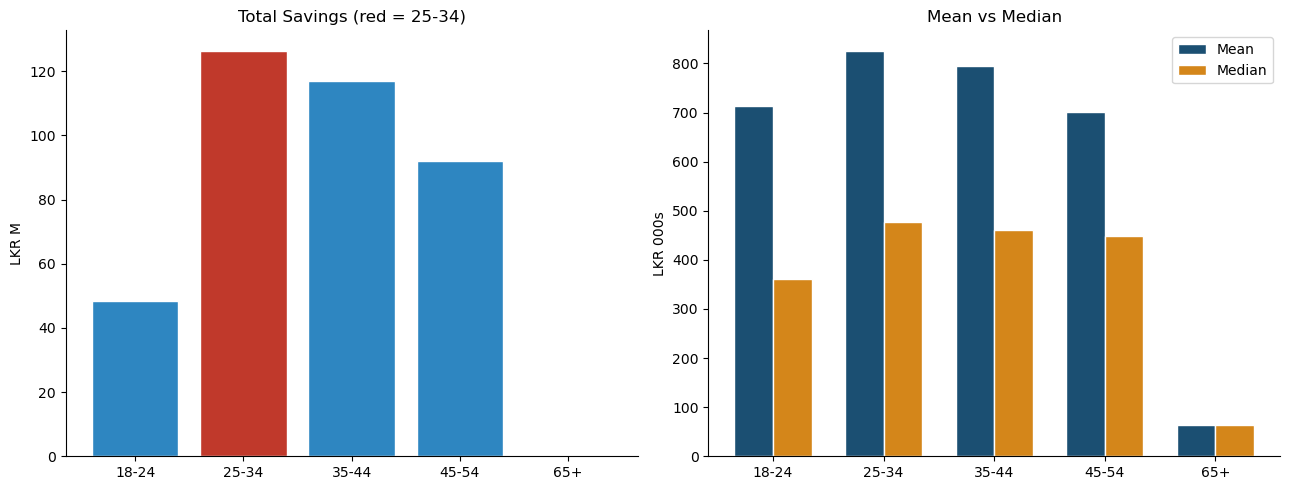

In [15]:
df_clean = df[df["Savings_Balance"] < 999_000_000]
age = df_clean.groupby("Age_Band", observed=True)["Savings_Balance"].agg(
    Total="sum", Mean="mean", Median="median", Count="count").reset_index()
age["Age_Band"] = age["Age_Band"].astype(str)
winner = age.loc[age["Total"].idxmax(), "Age_Band"]
print(age.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ["#C0392B" if b == winner else "#2E86C1" for b in age["Age_Band"]]

axes[0].bar(age["Age_Band"], age["Total"]/1e6, color=colors, edgecolor="white")
axes[0].set(title=f"Total Savings (red = {winner})", ylabel="LKR M")

x, w = np.arange(len(age)), 0.35
axes[1].bar(x-w/2, age["Mean"]/1e3,   w, color="#1B4F72", label="Mean",   edgecolor="white")
axes[1].bar(x+w/2, age["Median"]/1e3, w, color="#D4861A", label="Median", edgecolor="white")
axes[1].set_xticks(x); axes[1].set_xticklabels(age["Age_Band"])
axes[1].set(title="Mean vs Median", ylabel="LKR 000s"); axes[1].legend()

for ax in axes: ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

## Q1c - Growing vs Draining Savings

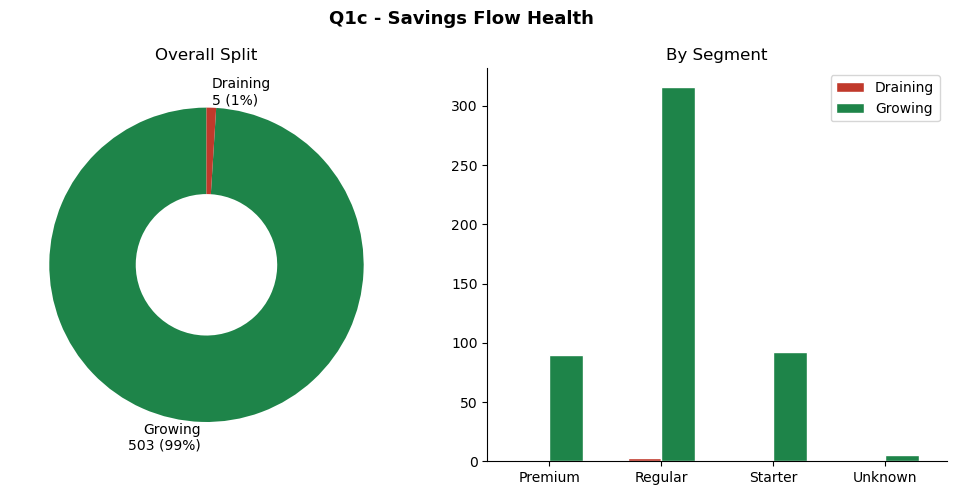

In [ ]:
df['Flow_Cat'] = np.where(df['Net_Monthly_Flow'] > 0, 'Growing', 'Draining')

growing, draining, n = (df['Net_Monthly_Flow'] > 0).sum(), (df['Net_Monthly_Flow'] <= 0).sum(), len(df)
growers = df.loc[df['Flow_Cat'] == 'Growing', 'Net_Monthly_Flow']

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Q1c - Savings Flow Health', fontsize=13, fontweight='bold')

axes[0].pie([growing, draining],
            labels=[f"Growing\n{growing} ({100*growing/n:.0f}%)", f"Draining\n{draining} ({100*draining/n:.0f}%)"],
            colors=['#1E8449', '#C0392B'], wedgeprops=dict(width=0.55), startangle=90)
axes[0].set_title('Overall Split')

(df.groupby(['Customer_Segment', 'Flow_Cat']).size().unstack(fill_value=0)
   .plot(kind='bar', ax=axes[1], color=['#C0392B', '#1E8449'], edgecolor='white', width=0.6))
axes[1].set(title='By Segment', xlabel='')
axes[1].tick_params(axis='x', rotation=0)
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].legend(title='')

plt.tight_layout()
plt.show()

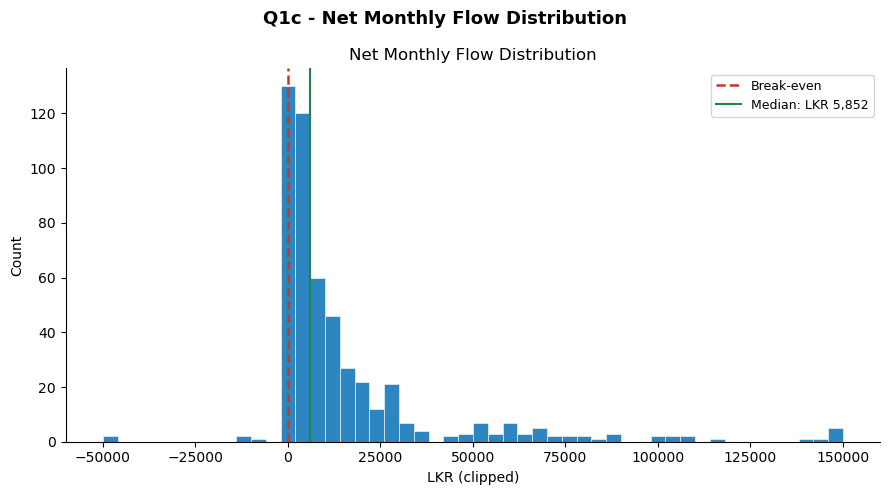

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('Q1c - Net Monthly Flow Distribution', fontsize=13, fontweight='bold')

med = df['Net_Monthly_Flow'].median()
ax.hist(df['Net_Monthly_Flow'].clip(-50000, 150000), bins=50, color='#2E86C1', edgecolor='white', linewidth=0.4)
ax.axvline(0, color='#C0392B', linestyle='--', linewidth=1.8, label='Break-even')
ax.axvline(med, color='#1E8449', linewidth=1.5, label=f"Median: LKR {med:,.0f}")
ax.set(title='Net Monthly Flow Distribution', xlabel='LKR (clipped)', ylabel='Count')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()